# Experimento comparativo — Clustering de departamentos por perfil de Dengue

> **Rol en el proyecto:** *experimento secundario*. El abordaje principal es la **regresión /
> serie temporal** (notebook `03_Regresion`). Aquí evaluamos si el dataset es **adecuado para
> clustering**, como parte de la comparación de los tres tipos de problema.

**Pregunta:** ¿se agrupan los departamentos en perfiles epidemiológicos bien diferenciados?

**Métricas (no supervisado):** método del **codo** (inercia), **Silhouette** y **Davies-Bouldin**.

### Corrección metodológica
- Se **excluyen los departamentos andinos/fríos con casi nulos casos** (MOQUEGUA=1, APURIMAC=11,
  AREQUIPA=28, PUNO=647): el *Aedes aegypti* casi no vive en altura, son **outliers** que antes
  inflaban artificialmente el Silhouette (un cluster aislaba a MOQUEGUA con 1 caso).
- El volumen de casos abarca varios órdenes de magnitud → se usa **escala logarítmica**.

## 0. Librerías

In [1]:
import sys; sys.path.append('../src')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 1. Construcción del perfil por departamento

In [2]:
from data import cargar_crudo, normalizar_edad, ORDEN_SEVERIDAD

df = cargar_crudo()
df = normalizar_edad(df)
df['semana'] = pd.to_numeric(df['semana'], errors='coerce')
df['severidad'] = df['enfermedad'].map(ORDEN_SEVERIDAD)
df = df[df['sexo'].isin(['M', 'F'])]
df = df[df['edad_anios'].between(0, 110)]
df = df.dropna(subset=['severidad', 'edad_anios', 'semana', 'departamento'])

perfil = df.groupby('departamento').agg(
    total_casos=('severidad', 'size'),
    edad_media=('edad_anios', 'mean'),
    prop_femenino=('sexo', lambda s: (s == 'F').mean()),
    tasa_con_signos=('severidad', lambda s: (s >= 1).mean()),
    tasa_grave=('severidad', lambda s: (s == 2).mean()),
    semana_pico=('semana', lambda s: s.value_counts().idxmax()),
)
print('Departamentos totales:', len(perfil))
perfil['total_casos'].sort_values()

Departamentos totales: 23


departamento
MOQUEGUA              1
APURIMAC             11
AREQUIPA             28
PUNO                647
PASCO              3802
CALLAO             8138
AYACUCHO           9946
HUANUCO           12119
CUSCO             15209
AMAZONAS          16805
JUNIN             26110
CAJAMARCA         29711
MADRE DE DIOS     32920
ANCASH            37661
SAN MARTIN        44518
TUMBES            45470
UCAYALI           52621
LAMBAYEQUE        56383
ICA               68620
LA LIBERTAD      100809
LORETO           107074
LIMA             122853
PIURA            237951
Name: total_casos, dtype: int64

### 1.1 Filtrado de outliers (regiones frías) y escala logarítmica

In [3]:
MIN_CASOS = 1000
perfil_f = perfil[perfil['total_casos'] >= MIN_CASOS].copy()
excluidos = perfil[perfil['total_casos'] < MIN_CASOS].index.tolist()
print('Excluidos (casi nulos casos):', excluidos)
print('Departamentos usados:', len(perfil_f))

# log10 del volumen (varios órdenes de magnitud)
perfil_f['total_casos'] = np.log10(perfil_f['total_casos'])
X = StandardScaler().fit_transform(perfil_f.values)
print('Matriz escalada:', X.shape)

Excluidos (casi nulos casos): ['APURIMAC', 'AREQUIPA', 'MOQUEGUA', 'PUNO']
Departamentos usados: 19
Matriz escalada: (19, 6)


## 2. Número óptimo de clústeres (codo + Silhouette)

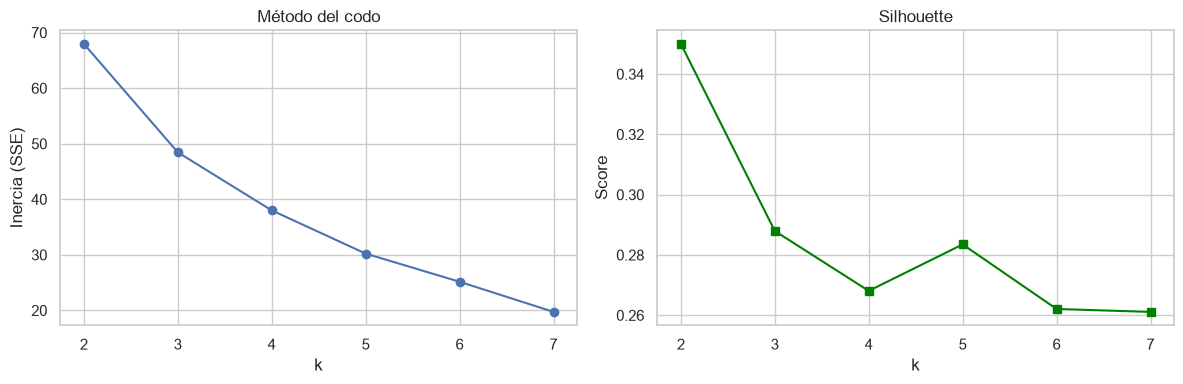

k seleccionado por Silhouette: 2 | Silhouette = 0.35


In [4]:
ks = range(2, 8)
inercias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, km.labels_))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.plot(list(ks), inercias, 'o-'); a1.set_title('Método del codo')
a1.set_xlabel('k'); a1.set_ylabel('Inercia (SSE)')
a2.plot(list(ks), silhouettes, 's-', color='green'); a2.set_title('Silhouette')
a2.set_xlabel('k'); a2.set_ylabel('Score'); plt.tight_layout(); plt.show()

K = list(ks)[int(np.argmax(silhouettes))]
print('k seleccionado por Silhouette:', K, '| Silhouette =', round(max(silhouettes), 3))

## 3. Clustering y métricas

In [5]:
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X)
agg = AgglomerativeClustering(n_clusters=K).fit(X)
for nombre, labels in [('KMeans', km.labels_), ('Jerárquico', agg.labels_)]:
    print(f'{nombre:<12} Silhouette={silhouette_score(X, labels):.3f}  '
          f'Davies-Bouldin={davies_bouldin_score(X, labels):.3f}')
perfil_f['cluster'] = km.labels_

KMeans       Silhouette=0.350  Davies-Bouldin=1.116
Jerárquico   Silhouette=0.350  Davies-Bouldin=1.116


## 4. Visualización con PCA

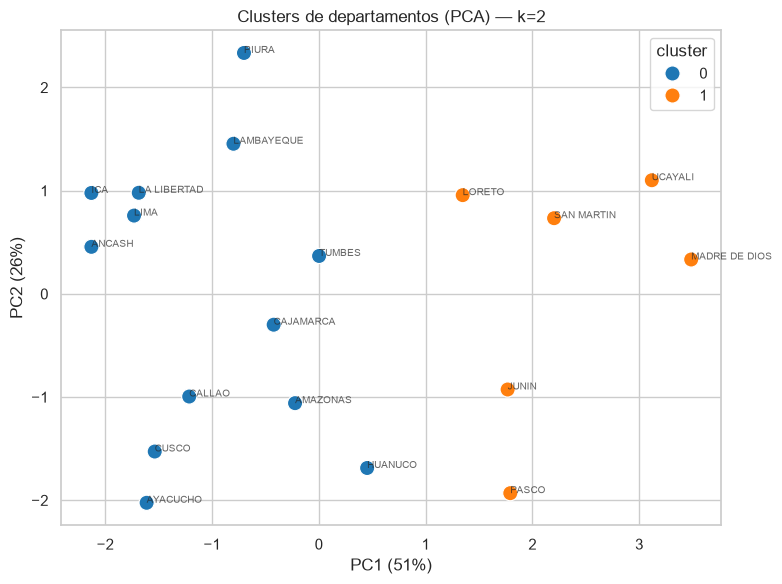

In [6]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=coords[:, 0], y=coords[:, 1], hue=km.labels_, palette='tab10', s=120)
for i, dep in enumerate(perfil_f.index):
    plt.annotate(dep, (coords[i, 0], coords[i, 1]), fontsize=7, alpha=0.7)
plt.title(f'Clusters de departamentos (PCA) — k={K}')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)')
plt.legend(title='cluster'); plt.tight_layout(); plt.show()

In [7]:
# Perfil medio de cada cluster (volviendo el volumen a escala real)
resumen = perfil_f.groupby('cluster').mean()
resumen['total_casos'] = (10 ** resumen['total_casos']).round(0)
resumen.round(3)

,total_casos,edad_media,prop_femenino,tasa_con_signos,tasa_grave,semana_pico
cluster,,,,,,
0,35561.0,31.388,0.535,0.086,0.003,14.538
1,30592.0,27.608,0.518,0.149,0.006,39.667


## 5. ¿Es adecuado el dataset para CLUSTERING?

> _Completar con los valores obtenidos._

| Métrica | ❌ Sin estructura | ⚠️ Débil | ✅ Razonable/Fuerte | Resultado |
|---|---|---|---|---|
| Silhouette | < 0.25 | 0.25–0.50 | 0.50–0.70 / > 0.70 | ~0.35 ⚠️ |
| Davies-Bouldin (menor=mejor) | > 2 | 1–2 | < 1 | ~1.0 ⚠️ |

**Conclusión:** tras corregir los outliers, la estructura de clusters es **débil** (Silhouette
≈ 0.35). El dataset **no es claramente adecuado para clustering**; los departamentos se
diferencian sobre todo por **volumen de casos**, no por perfiles cualitativos marcados.

> Este resultado, junto con el de clasificación, **confirma que la regresión / serie temporal
> es el único abordaje claramente adecuado** para este dataset (ver `03_Regresion`).